# Домашняя работа 9: Object Tracking

В этом домашнем задании мы будем работать с задачей отслеживания объектов (object tracking) на датасете MOT15. 

План домашнего задания:
1. Реализация класса Dataset для работы с MOT15
2. Детекция объектов с помощью YOLOv8
3. Трекинг объектов с использованием DeepSORT
4. Визуализация результатов трекинга
5. Подсчет объектов, пересекающих заданную линию

Импортируем необходимые библиотеки:

In [ ]:
# Установим Ultralytics и DeepSORT
#!pip install ultralytics deep-sort-realtime

# Скачаем данные
#!wget https://motchallenge.net/data/MOT15.zip -O MOT15.zip
#!unzip -q MOT15.zip

In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional

import torch
from torch.utils.data import Dataset
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import matplotlib.pyplot as plt

## Часть 1: Работа с датасетом MOT15

В первой части мы реализуем класс для работы с датасетом MOT15. Этот датасет содержит последовательности изображений с размеченными объектами для задачи трекинга.

Реализуйте класс `MOT15Dataset`, который должен:
1. Принимать путь к директории с данными и название последовательности (sequence)
2. Загружать список изображений для данной последовательности
3. Предоставлять метод для получения изображения по индексу
4. Загружать ground truth разметку, если она доступна

In [3]:
# BEGIN STUDENT
class MOT15Dataset(Dataset):
    def __init__(self, data_root: str, sequence: str):
        """
        Args:
            data_root: путь к корневой директории датасета
            sequence: название последовательности (например, 'TUD-Stadtmitte')
        """
        pass

    def __len__(self) -> int:
        pass

    def __getitem__(self, idx: int) -> tuple[np.ndarray, Optional[np.ndarray]]:
        """
        Returns:
            tuple: (изображение, ground truth разметка если доступна)
        """
        pass
# END STUDENT

In [4]:
dataset = MOT15Dataset("MOT15/train", "ADL-Rundle-6")
print(f"Dataset length: {len(dataset)}")
    
img, gt = dataset[0]
print(f"Image shape: {img.shape}")
if gt is not None:
    print(f"Ground truth shape: {gt.shape}")
else:
    print("No ground truth available")
        
assert isinstance(img, np.ndarray), "Image should be a numpy array"
assert len(img.shape) == 3, "Image should have 3 dimensions"
assert img.shape[2] == 3, "Image should have 3 channels"

Dataset length: 525
Image shape: (1080, 1920, 3)
Ground truth shape: (4, 5)


Загрузите код в LMS.

## Часть 2: Детекция объектов с YOLOv8

В этой части мы будем использовать предобученную модель YOLOv8-M для детекции объектов на кадрах видео. 
Результаты детекции нужно сохранить в формате, подходящем для дальнейшего трекинга.

Формат файла с детекциями:
- Cписок словарей, где каждый словарь содержит:
  - 'frame': номер кадра (начиная с 1)
  - 'bb_left': x-координата левого верхнего угла ограничивающей рамки
  - 'bb_top': y-координата левого верхнего угла ограничивающей рамки
  - 'bb_width': ширина ограничивающей рамки
  - 'bb_height': высота ограничивающей рамки
  - 'conf': уверенность детекции (от 0 до 1)

Пример записи в JSON:
{
    "frame": 1,
    "bb_left": 100.5,
    "bb_top": 150.2,
    "bb_width": 50.0,
    "bb_height": 100.0,
    "conf": 0.95
}

Важно:
1. Сохраняются только детекции людей
2. Все координаты и размеры указываются в пикселях, в формате float
3. Номера кадров начинаются с 1
4. Уверенность детекции (conf) должна быть в диапазоне [0, 1]

In [5]:
# BEGIN STUDENT
def detect_objects(dataset: MOT15Dataset, output_path: str):
    """
    Детекция объектов на последовательности изображений
    Args:
        dataset: датасет с изображениями
        output_path: путь для сохранения результатов
    """
    pass
# END STUDENT

In [6]:
# Создаем датасет для последовательности ADL-Rundle-6
dataset = MOT15Dataset("MOT15/train", "ADL-Rundle-6")

# Путь для сохранения результатов
output_path = "yolo_detections.json"

# Запускаем детекцию объектов
detect_objects(dataset, output_path)

# Проверяем результаты
with open(output_path, 'r') as f:
    detections = json.load(f)

print(f"Всего найдено {len(detections)} детекций")
print("\nПример первой детекции:")
print(json.dumps(detections[0], indent=2, ensure_ascii=False))

Всего найдено 5326 детекций

Пример первой детекции:
{
  "frame": 1,
  "bb_left": 1704.61474609375,
  "bb_top": 388.6354064941406,
  "bb_width": 161.8076171875,
  "bb_height": 339.8561706542969,
  "conf": 0.8707222938537598
}


Полученный json залейте в LMS.

## Часть 3: Трекинг с DeepSORT

В этой части мы используем алгоритм DeepSORT для трекинга объектов на основе полученных детекций YOLOv8. 
DeepSORT не только использует информацию о положении объектов, но и извлекает визуальные признаки для более надежного отслеживания.

Формат файла с результатами трекинга:
- Список словарей, где каждый словарь содержит:
  - 'frame': номер кадра (начиная с 1)
  - 'id': уникальный идентификатор трека (целое число)
  - 'bb_left': x-координата левого верхнего угла ограничивающей рамки
  - 'bb_top': y-координата левого верхнего угла ограничивающей рамки
  - 'bb_width': ширина ограничивающей рамки
  - 'bb_height': высота ограничивающей рамки

Пример записи в JSON:
{
    "frame": 1,
    "id": 5,
    "bb_left": 100.5,
    "bb_top": 150.2,
    "bb_width": 50.0,
    "bb_height": 100.0
}

Важно:
1. ID трека является уникальным для каждого отслеживаемого объекта и сохраняется между кадрами
2. В выходной файл попадают только подтвержденные треки (is_confirmed() == True)
3. Все координаты и размеры указываются в пикселях, в формате float
4. Номера кадров начинаются с 1
5. Один и тот же объект (ID) может появляться в нескольких последовательных кадрах

In [7]:
# BEGIN STUDENT
def track_objects(dataset: MOT15Dataset, detections_path: str, output_path: str):
    """
    Трекинг объектов с использованием DeepSORT
    Args:
        dataset: датасет с изображениями
        detections_path: путь к файлу с детекциями
        output_path: путь для сохранения результатов трекинга
    """
    pass
# END STUDENT

In [8]:
# Создаем датасет для последовательности ADL-Rundle-6
dataset = MOT15Dataset("MOT15/train", "ADL-Rundle-6")

# Пути к файлам с детекциями и для сохранения результатов
detections_path = "yolo_detections.json"
output_path = "tracking_results.json"

# Запускаем трекинг объектов
track_objects(dataset, detections_path, output_path)

# Проверяем результаты
with open(output_path, 'r') as f:
    tracks = json.load(f)

# Анализируем результаты
unique_tracks = len(set(t['id'] for t in tracks))
total_detections = len(tracks)
frames_count = max(t['frame'] for t in tracks)

print(f"Статистика трекинга:")
print(f"Всего уникальных треков: {unique_tracks}")
print(f"Всего детекций в треках: {total_detections}")
print(f"Количество обработанных кадров: {frames_count}")
print("\nПример первой записи трека:")
print(json.dumps(tracks[0], indent=2, ensure_ascii=False))

# Распределение треков по кадрам
tracks_per_frame = {}
for track in tracks:
    frame = track['frame']
    if frame not in tracks_per_frame:
        tracks_per_frame[frame] = 0
    tracks_per_frame[frame] += 1

print(f"\nСреднее количество треков на кадр: {np.mean(list(tracks_per_frame.values())):.2f}")

Статистика трекинга:
Всего уникальных треков: 52
Всего детекций в треках: 7829
Количество обработанных кадров: 525

Пример первой записи трека:
{
  "frame": 3,
  "id": 1,
  "bb_left": 1688.8436856249493,
  "bb_top": 388.2458136602638,
  "bb_width": 162.16190029567906,
  "bb_height": 340.5903987971201
}

Среднее количество треков на кадр: 14.97


Полученный json залейте в LMS.

## Часть 4: Визуализация результатов

Реализуйте функцию для визуализации результатов трекинга. Функция должна возвращать изображение с отрисованными bounding box'ами и ID объектов.

In [9]:
# BEGIN STUDENT
def visualize_tracking(image: np.ndarray, tracks: list[dict]) -> np.ndarray:
    """
    Визуализация результатов трекинга на изображении
    Args:
        image: исходное изображение
        tracks: список треков для текущего кадра
    Returns:
        np.ndarray: изображение с визуализацией
    """
    pass
# END STUDENT

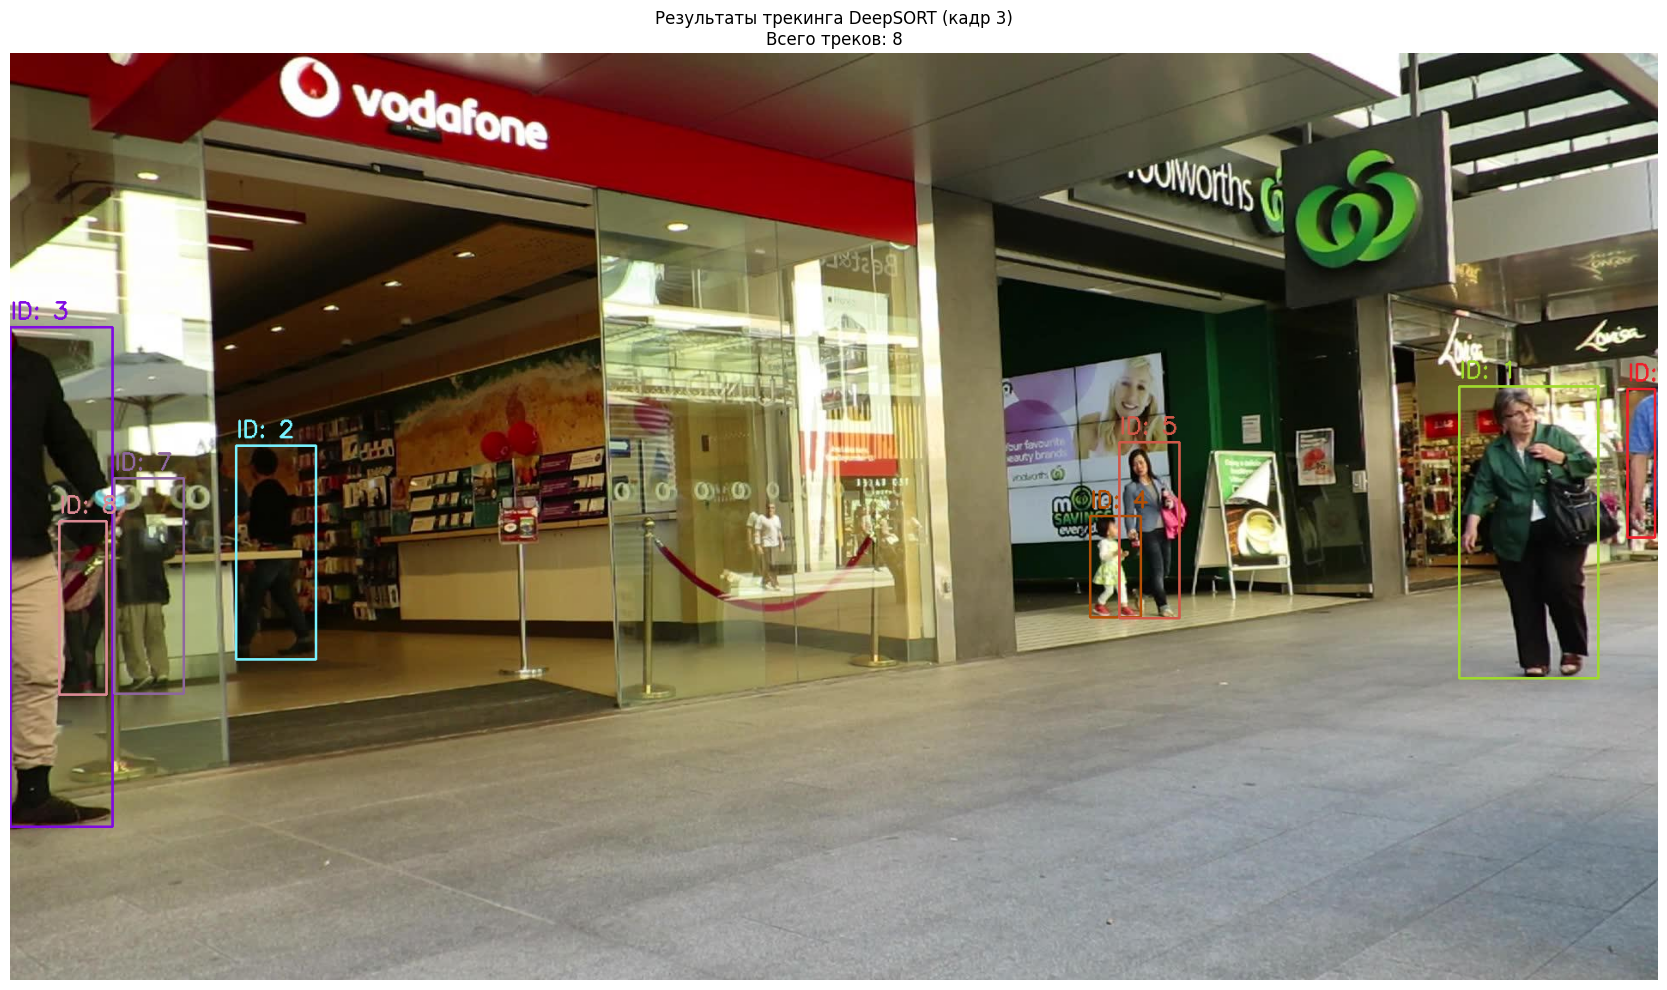

In [17]:
# Создаем датасет для последовательности ADL-Rundle-6
dataset = MOT15Dataset("MOT15/train", "ADL-Rundle-6")

# Загружаем результаты детекций и трекинга
with open("yolo_detections.json", 'r') as f:
    detections = json.load(f)
with open("tracking_results.json", 'r') as f:
    tracks = json.load(f)

# Выбираем кадр для визуализации (например, 100-й кадр)
frame_idx = 2
image, _ = dataset[frame_idx]

# Получаем детекции и треки для выбранного кадра
#frame_detections = [d for d in detections if d['frame'] == frame_idx + 1]
frame_tracks = [t for t in tracks if t['frame'] == frame_idx + 1]

# Создаем фигуру с двумя изображениями
plt.figure(figsize=(20, 10))

# Визуализируем результаты трекинга
track_vis = visualize_tracking(image, frame_tracks)
plt.imshow(track_vis)
plt.title(f'Результаты трекинга DeepSORT (кадр {frame_idx + 1})\nВсего треков: {len(frame_tracks)}')
plt.axis('off')

plt.tight_layout()
plt.show()

Код функции загрузите в LMS.

## Часть 5: Подсчет пересечений

В этой части мы реализуем функционал подсчета количества людей, пересекающих заданную линию на видео. Это важная задача для различных приложений, таких как анализ потока посетителей в торговых центрах, подсчет пассажиров на станциях или мониторинг движения пешеходов на улицах.

Входные данные:
1. Результаты трекинга в формате JSON, где каждая запись содержит:
   - 'frame': номер кадра (начиная с 1)
   - 'id': уникальный идентификатор трека
   - 'bb_left': x-координата левого верхнего угла
   - 'bb_top': y-координата левого верхнего угла
   - 'bb_width': ширина bbox'а
   - 'bb_height': высота bbox'а

2. Линия подсчета, заданная двумя точками:
   - Начальная точка (x1, y1)
   - Конечная точка (x2, y2)

Алгоритм работы:
1. Для каждого уникального трека (ID):
   - Отслеживаем последовательные позиции центра bbox'а
   - Проверяем пересечение траектории движения с заданной линией
   - Учитываем только первое пересечение линии каждым объектом

2. Определение пересечения:
   - Рассматриваем движение объекта как отрезок между последовательными положениями
   - Используем алгоритм пересечения двух отрезков
   - Учитываем направление движения для корректного подсчета

Выходные данные - количество уникальных пересечений линии.

In [11]:
# BEGIN STUDENT
def count_line_crossings(tracks: list[dict], line_start: tuple[int, int], line_end: tuple[int, int]) -> int:
    """
    Подсчет количества пересечений линии объектами
    Args:
        tracks: список треков
        line_start: начальная точка линии (x, y)
        line_end: конечная точка линии (x, y)
    Returns:
        int: количество пересечений
    """
    pass
# END STUDENT

In [12]:
# Загружаем результаты трекинга
with open("tracking_results.json", 'r') as f:
    tracks = json.load(f)

# Определяем линию подсчета
# Для ADL-Rundle-3 определим вертикальную линию примерно в центре кадра
line_start = (960, 0)    # Верхняя точка линии (x=960, y=0)
line_end = (960, 1080)   # Нижняя точка линии (x=960, y=1080)

# Подсчитываем пересечения
crossings = count_line_crossings(tracks, line_start, line_end)

# Выводим статистику
print(f"Статистика пересечений:")
print(f"Всего пересечений линии: {crossings}")
print(f"Количество уникальных треков: {len(set(t['id'] for t in tracks))}")
print(f"Общее количество детекций в треках: {len(tracks)}")

Статистика пересечений:
Всего пересечений линии: 113
Количество уникальных треков: 230
Общее количество детекций в треках: 14754


Код функции загрузите в LMS.

# Заключение

В данном домашнем задании мы рассмотрели полный пайплайн системы отслеживания объектов, состоящий из нескольких ключевых этапов:

1. Работа с данными:
   - Реализовали класс для загрузки и обработки датасета MOT15
   - Научились работать с последовательностями изображений и аннотациями

2. Детекция объектов:
   - Использовали предобученную модель YOLOv8 для обнаружения людей на фреймах

3. Трекинг объектов:
   - Применили алгоритм DeepSORT для отслеживания объектов

4. Визуализация и анализ:
   - Создали инструменты для визуализации результатов трекинга
   - Реализовали подсчет пересечений заданной линии

Важно отметить, что каждый этап пайплайна может быть дополнительно оптимизирован и настроен под конкретную задачу, что открывает широкие возможности для дальнейшего развития системы.